# Kiểm tra embedding V-Market

Notebook này kiểm tra trực tiếp output của notebook 02 trước khi train RQ-VAE. Mục tiêu là xác định embedding có NaN, norm bất thường, quá nhiều vector trùng, thiếu phương sai hoặc phân cụm kém hay không.

Notebook chạy trên CPU và chỉ lấy sample từ file NPY bằng memory map.

## 1. Cấu hình

Đổi `EMBEDDING_ROOT` thành thư mục chứa hai file output của notebook 02.

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import MiniBatchKMeans

EMBEDDING_ROOT = Path("../dataset/embeddings")
SAMPLE_SIZE = 100_000
PAIR_COUNT = 50_000
SEED = 2026

EMBEDDING_PATH = EMBEDDING_ROOT / "global_product_embeddings.f16.npy"
INDEX_PATH = EMBEDDING_ROOT / "global_embedding_index.parquet"

if not EMBEDDING_PATH.is_file() or not INDEX_PATH.is_file():
    raise FileNotFoundError(f"Embedding artifacts were not found in {EMBEDDING_ROOT.resolve()}")

print("Embedding root:", EMBEDDING_ROOT.resolve())

Embedding root: /mnt/d/VSF/VSF-MiniApp-Ecommerce/ai-recommendation/dataset/embeddings


## 2. Đọc và kiểm tra contract

In [4]:
embeddings = np.load(EMBEDDING_PATH, mmap_mode="r")
index = pd.read_parquet(INDEX_PATH, columns=["product_index", "product_id"])

assert embeddings.ndim == 2
assert len(embeddings) == len(index)
assert np.array_equal(index["product_index"].to_numpy(), np.arange(len(index)))
assert index["product_id"].notna().all()
assert index["product_id"].is_unique

print("Shape:", embeddings.shape)
print("Dtype:", embeddings.dtype)
print("Products:", f"{len(index):,}")
print("File size:", f"{EMBEDDING_PATH.stat().st_size / 2**30:.2f} GiB")

Shape: (1410675, 256)
Dtype: float16
Products: 1,410,675
File size: 0.67 GiB


## 3. Lấy sample cố định

Sample được dùng cho các phép tính chẩn đoán để notebook vẫn chạy được trên máy local.

In [5]:
rng = np.random.default_rng(SEED)
sample_size = min(SAMPLE_SIZE, len(embeddings))
sample_rows = rng.choice(len(embeddings), size=sample_size, replace=False)
sample = np.asarray(embeddings[sample_rows], dtype=np.float32)

print("Sample shape:", sample.shape)

Sample shape: (100000, 256)


## 4. Finite values, norm và duplicate

,value
finite_rate,1.000000
norm_min,0.999726
norm_mean,0.999999
norm_max,1.000254
duplicate_rate_in_sample,0.000900
near_constant_dimensions,0.000000
dimension_std_mean,0.043903


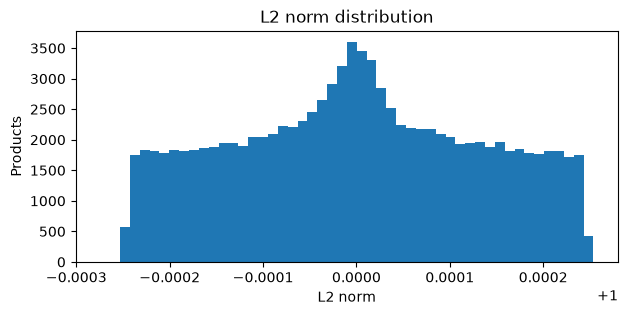

In [6]:
finite_rate = float(np.isfinite(sample).mean())
norms = np.linalg.norm(sample, axis=1)
unique_rows = np.unique(sample, axis=0).shape[0]
duplicate_rate = 1 - unique_rows / len(sample)
dimension_std = sample.std(axis=0)
near_constant_dimensions = int((dimension_std < 1e-6).sum())

basic_stats = pd.Series({
    "finite_rate": finite_rate,
    "norm_min": float(norms.min()),
    "norm_mean": float(norms.mean()),
    "norm_max": float(norms.max()),
    "duplicate_rate_in_sample": duplicate_rate,
    "near_constant_dimensions": near_constant_dimensions,
    "dimension_std_mean": float(dimension_std.mean()),
})
display(basic_stats.to_frame("value"))

plt.figure(figsize=(7, 3))
plt.hist(norms, bins=50)
plt.title("L2 norm distribution")
plt.xlabel("L2 norm")
plt.ylabel("Products")
plt.show()

## 5. Cosine similarity giữa các cặp ngẫu nhiên

Nếu gần như mọi cặp đều có cosine rất cao, embedding có thể thiếu khả năng phân biệt sản phẩm.

,cosine
min,0.085559
p05,0.312032
mean,0.496407
p95,0.721571
max,0.991843


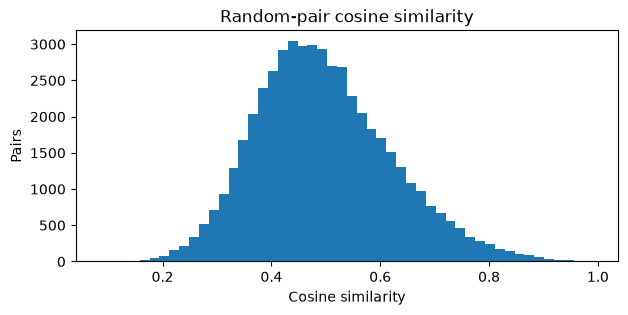

In [7]:
pair_count = min(PAIR_COUNT, len(sample))
left = rng.integers(0, len(sample), size=pair_count)
right = rng.integers(0, len(sample), size=pair_count)
same = left == right
right[same] = (right[same] + 1) % len(sample)

denominator = norms[left] * norms[right]
cosine = (sample[left] * sample[right]).sum(axis=1) / np.maximum(denominator, 1e-12)

cosine_stats = pd.Series({
    "min": float(cosine.min()),
    "p05": float(np.quantile(cosine, 0.05)),
    "mean": float(cosine.mean()),
    "p95": float(np.quantile(cosine, 0.95)),
    "max": float(cosine.max()),
})
display(cosine_stats.to_frame("cosine"))

plt.figure(figsize=(7, 3))
plt.hist(cosine, bins=50)
plt.title("Random-pair cosine similarity")
plt.xlabel("Cosine similarity")
plt.ylabel("Pairs")
plt.show()

## 6. Effective dimension

Phép tính này cho biết thông tin thực tế trải trên bao nhiêu chiều thay vì chỉ nhìn kích thước vector là 256.

In [8]:
centered = sample - sample.mean(axis=0, keepdims=True)
covariance = centered.T @ centered / max(1, len(centered) - 1)
eigenvalues = np.maximum(np.linalg.eigvalsh(covariance), 0)[::-1]
variance_ratio = eigenvalues / eigenvalues.sum()
effective_dimension = float(eigenvalues.sum() ** 2 / np.square(eigenvalues).sum())

dimension_stats = pd.Series({
    "effective_dimension": effective_dimension,
    "variance_top_10": float(variance_ratio[:10].sum()),
    "variance_top_32": float(variance_ratio[:32].sum()),
    "variance_top_64": float(variance_ratio[:64].sum()),
})
display(dimension_stats.to_frame("value"))

,value
effective_dimension,26.474632
variance_top_10,0.516281
variance_top_32,0.767789
variance_top_64,0.881292


## 7. K-means probe với 256 cụm

Đây không phải RQ-VAE. Nó chỉ kiểm tra embedding có thể phân bố tương đối đều vào 256 cụm hay không.

,value
used_clusters,256.000000
effective_clusters,232.164489
largest_cluster_share,0.014120
top_5_share,0.051120
mean_squared_distance,0.168534


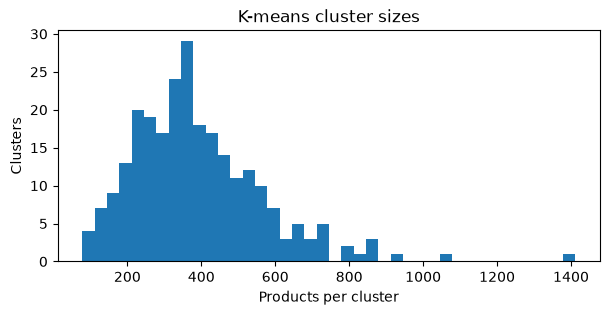

In [9]:
kmeans = MiniBatchKMeans(
    n_clusters=256,
    batch_size=4096,
    max_iter=100,
    n_init=3,
    random_state=SEED,
)
labels = kmeans.fit_predict(sample)
counts = np.bincount(labels, minlength=256)
probabilities = counts / counts.sum()
positive = probabilities > 0
entropy = -(probabilities[positive] * np.log(probabilities[positive])).sum()

kmeans_stats = pd.Series({
    "used_clusters": int(positive.sum()),
    "effective_clusters": float(np.exp(entropy)),
    "largest_cluster_share": float(probabilities.max()),
    "top_5_share": float(np.sort(probabilities)[-5:].sum()),
    "mean_squared_distance": float(kmeans.inertia_ / len(sample)),
})
display(kmeans_stats.to_frame("value"))

plt.figure(figsize=(7, 3))
plt.hist(counts, bins=40)
plt.title("K-means cluster sizes")
plt.xlabel("Products per cluster")
plt.ylabel("Clusters")
plt.show()

## 8. Kết luận nhanh

In [10]:
warnings = []
if finite_rate < 1:
    warnings.append("Sample contains NaN or infinite values.")
if duplicate_rate > 0.01:
    warnings.append("More than 1% of sampled embeddings are exact duplicates.")
if near_constant_dimensions > 0:
    warnings.append("Some embedding dimensions are nearly constant.")
if effective_dimension < 32:
    warnings.append("The embedding has a low effective dimension.")
if kmeans_stats["effective_clusters"] < 128:
    warnings.append("K-means uses fewer than 128 effective clusters.")

if warnings:
    print("Potential data issues:")
    for warning in warnings:
        print("-", warning)
else:
    print("No obvious embedding-data issue was found in the sample.")

if 0.95 <= norms.mean() <= 1.05:
    print("The embeddings are L2-normalized.")

Potential data issues:
- The embedding has a low effective dimension.
The embeddings are L2-normalized.
